# Step 03 — Rolled-out flow matching

**A Computer Vision Project — *Flow Matching as a Layer*** · Stage 2
University of Haifa

---

## Purpose

Train the *same* velocity network with the **rolled-out** objective and compare it against
both the Stage 1 prototype baseline and step 2's standard FM.

Starting from $\hat z_0 = \hat z_i$, apply the full $T$-step Euler sequence used at inference,
and supervise only where the feature ends up:

$$\hat z_{k+1} = \hat z_k + \tfrac{1}{T}\,v_\theta\!\left(\hat z_k, \tfrac{k}{T}\right),
\qquad \mathcal{L}_\mathrm{roll} = \lVert \hat z_T - p_{y_i} \rVert_2^2$$

Gradients flow back through **all $T$ velocity predictions**.

## What this changes, and what it does not

The network, its size, the optimiser, the batch size, the epoch budget, the k-shot subsets and
the seeds are **identical to step 2**. Only the loss differs — which is what makes the
comparison a statement about the objective.

| | Standard FM (step 2) | Rolled-out FM (this step) |
| --- | --- | --- |
| States seen in training | on the ideal straight path | the network's **own** rollout |
| Supervision | every intermediate velocity | the final position only |
| Train/inference mismatch | yes | **none, by construction** |
| Depends on $T$ | no — one model serves all $T$ | **yes** — one model per $T$ |
| Models to train | 27 | **54** |
| Cost per epoch | 1 forward/backward | $T$ forward/backward |

## Sections

| # | Section |
| --- | --- |
| 1 | Setup |
| 2 | The mismatch rolled-out training removes |
| 3 | Train the 54 models |
| 4 | Results — against the baseline and against standard FM |
| 5 | Training curves and stability |
| 6 | Why the two objectives disagree |
| 7 | Save artefacts |
| 8 | Manifest |

## A note on gradient clipping

Backpropagating through $T$ composed Euler steps can amplify gradients. Without clipping, the
rolled-out objective produced a late-training loss spike in one of 54 runs
(`resnet18`/Aircraft, $K=\text{full}$, $T=4$, seed 2: loss $0.022$ at epoch 97
$\rightarrow 24.5$ at epoch 98), which a fixed-budget run cannot recover from or ignore.

Gradient-norm clipping at $1.0$ is therefore applied — and applied to **both** objectives,
not only the one that needed it, so the two remain configuration-identical. Section 5 keeps
the unclipped evidence, because the instability is itself a real difference between the
objectives and worth reporting rather than quietly removing.

## 1 · Setup

Same prototypes, same features, same configuration object as step 2 — imported rather than
restated, so the two steps cannot drift apart.

In [1]:
from __future__ import annotations

import json
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from cvlab.data import make_kshot_subset
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab.prototypes import l2_normalize

from cvlabfm.flow import (FlowConfig, VelocityNet, classify_by_prototype, euler_rollout,
                          evaluate_flow, train_rolled_out_fm)
from cvlabfm.paths import RESULTS_ROOT, STAGE1_RESULTS, step_dirs

apply_style()
art = ArtifactWriter(*step_dirs("03_rolled_out_fm"))

COMBOS: list[tuple[str, str]] = [
    ("resnet18", "DTD"),
    ("resnet18", "FGVC-Aircraft"),
    ("dinov2", "FGVC-Aircraft"),
]
K_SETTINGS: list[int | str] = [5, 10, "full"]
SEEDS: list[int] = [0, 1, 2]
T_VALUES: list[int] = [4, 12]
ORDER = ["5", "10", "full"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG = FlowConfig()          # identical to step 2 - not re-tuned

REPRESENTATIVE = {(enc, ds, "full", 0) for enc, ds in COMBOS}

print(f"device : {DEVICE}")
print(f"config : {CONFIG.as_dict()}")

device : cuda
config : {'hidden_dim': 512, 'n_hidden': 2, 'activation': 'SiLU', 'optimizer': 'AdamW', 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'epochs': 100, 'max_grad_norm': 1.0, 'checkpoint_selection': 'none - final epoch, fixed budget'}


In [2]:
proto_payload = torch.load(RESULTS_ROOT / "prototypes.pt", weights_only=False)
prototypes = proto_payload["prototypes"]


def proto_key(encoder: str, dataset: str, K, seed) -> str:
    tag = "NA" if K == "full" else str(seed)
    return f"{encoder}__{dataset}__K{K}__seed{tag}"


features = {(enc, ds, split): load_features(enc, ds, split)
            for enc, ds in COMBOS for split in ("train", "test")}

# The two references this step is measured against.
baseline = pd.read_csv(STAGE1_RESULTS / "prototype_runs.csv")
baseline["K"] = baseline["K"].astype(str)
baseline_acc = (baseline.groupby(["encoder", "dataset", "K"])["test_acc"]
                .mean().mul(100).round(4).to_dict())

standard = pd.read_csv(RESULTS_ROOT / "standard_fm_runs.csv")
standard["K"] = standard["K"].astype(str)
standard_acc = (standard.groupby(["encoder", "dataset", "K", "T"])["test_acc"]
                .mean().round(4).to_dict())

print(f"{len(prototypes)} prototype sets | {len(baseline_acc)} baseline cells | "
      f"{len(standard_acc)} standard-FM cells")

21 prototype sets | 9 baseline cells | 18 standard-FM cells


## 2 · The mismatch rolled-out training removes

Step 2's objective only ever supervised points **on** the straight line between a feature and
its prototype. At inference the network is instead fed states it generated itself.

The figure below makes that concrete using step 2's *trained* model: it rolls real test
features forward $T = 12$ steps and draws the actual trajectory against the straight line the
training objective assumed. Where the two diverge is exactly the region standard FM never
supervised — and exactly what rolled-out training will now train on.

  saved plot  -> plots/train_inference_mismatch.png


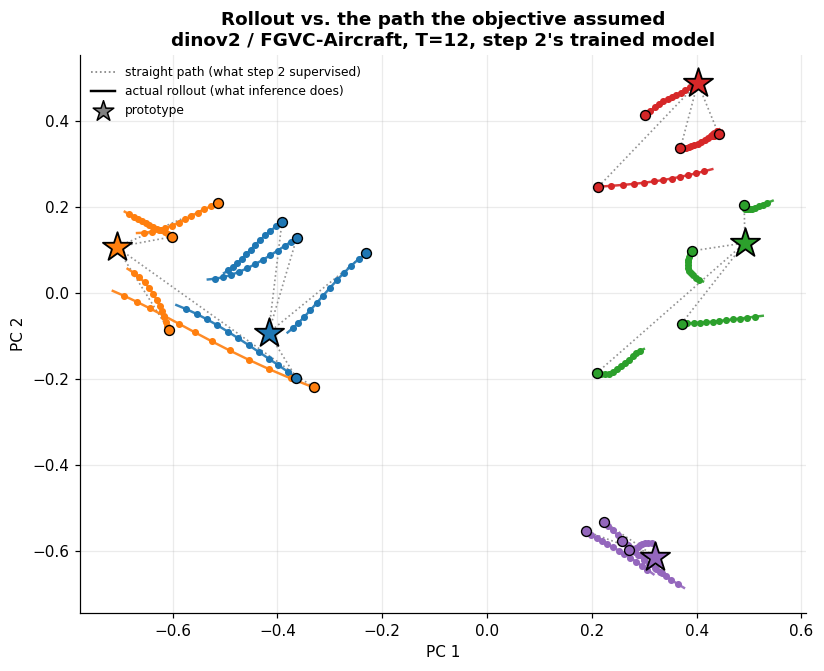

In [3]:
from sklearn.decomposition import PCA

std_models = torch.load(RESULTS_ROOT / "standard_fm_models.pt", weights_only=False)

enc, ds = "dinov2", "FGVC-Aircraft"
te = features[(enc, ds, "test")]
protos = prototypes[proto_key(enc, ds, "full", None)]

net = VelocityNet(te.dim, CONFIG.hidden_dim, CONFIG.n_hidden)
net.load_state_dict(std_models["state_dicts"][f"{enc}__{ds}__Kfull__seed0"])
net.eval()

chosen = np.arange(0, te.n_classes, max(1, te.n_classes // 5))[:5]
mask = np.isin(te.labels.numpy(), chosen)
z_sub, y_sub = l2_normalize(te.features[mask]), te.labels[mask]

with torch.no_grad():
    _, traj = euler_rollout(net, z_sub, T=12, return_trajectory=True)

pca = PCA(n_components=2, random_state=0).fit(
    torch.cat([z_sub, protos[chosen]]).numpy())
P = pca.transform(protos[chosen].numpy())
palette = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(7.6, 6.2))
rng = np.random.default_rng(0)
for j, c in enumerate(chosen):
    idx = np.where((y_sub == c).numpy())[0]
    for i in rng.choice(idx, size=min(4, len(idx)), replace=False):
        path = pca.transform(traj[i].numpy())
        ax.plot(path[:, 0], path[:, 1], color=palette[j], lw=1.6, alpha=0.9, zorder=3)
        ax.scatter(path[1:-1, 0], path[1:-1, 1], s=13, color=palette[j], zorder=4)
        ax.plot([path[0, 0], P[j, 0]], [path[0, 1], P[j, 1]],
                color="grey", ls=":", lw=1.1, alpha=0.85, zorder=2)
        ax.scatter(*path[0], s=42, color=palette[j], edgecolor="black",
                   linewidth=0.9, zorder=5)
    ax.scatter(*P[j], marker="*", s=400, color=palette[j],
               edgecolor="black", linewidth=1.2, zorder=6)

ax.plot([], [], color="grey", ls=":", lw=1.1, label="straight path (what step 2 supervised)")
ax.plot([], [], color="black", lw=1.6, label="actual rollout (what inference does)")
ax.scatter([], [], marker="*", s=200, color="grey", edgecolor="black", label="prototype")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(fontsize=8, loc="best")
ax.set_title(f"Rollout vs. the path the objective assumed\n{enc} / {ds}, T=12, "
             "step 2's trained model", fontsize=12, fontweight="bold")
fig.tight_layout()
art.figure(fig, "train_inference_mismatch")
plt.show()

## 3 · Train the 54 models

3 combinations $\times$ 3 training sizes $\times$ 3 seeds $\times$ 2 values of $T$. Each model
is evaluated **only** at the $T$ it was trained with, since $T$ is baked into what the
rollout backpropagated through during training.

In [4]:
run_rows: list[dict] = []
curves: dict[str, list[float]] = {}
predictions: dict[str, torch.Tensor] = {}
kept_models: dict[str, dict] = {}

sweep_start = time.perf_counter()

for enc, ds in COMBOS:
    tr, te = features[(enc, ds, "train")], features[(enc, ds, "test")]
    print(f"=== {enc} / {ds}  ({tr.n_classes} classes, {tr.dim}-d) ===")

    for K in K_SETTINGS:
        for seed in SEEDS:
            protos = prototypes[proto_key(enc, ds, K, seed)]

            if K == "full":
                sub_x, sub_y = tr.features, tr.labels
            else:
                sub_x, sub_y = make_kshot_subset(tr.features, tr.labels, k=K, seed=seed)

            for T in T_VALUES:
                net, history, elapsed = train_rolled_out_fm(
                    sub_x, sub_y, protos, T=T, seed=seed, config=CONFIG, device=DEVICE)

                # Trained with this T, so evaluated only at this T.
                accs, preds = evaluate_flow(net, te.features, te.labels, protos,
                                            [T], device=DEVICE)

                key = f"{enc}__{ds}__K{K}__seed{seed}__T{T}"
                curves[key] = history
                predictions[key] = preds[T]

                std = standard_acc[(enc, ds, str(K), T)]
                base = baseline_acc[(enc, ds, str(K))]
                run_rows.append({
                    "encoder": enc, "dataset": ds, "K": str(K), "seed": seed, "T": T,
                    "method": "rolled_out_fm",
                    "n_train": int(sub_x.shape[0]),
                    "test_acc": 100 * accs[T],
                    "final_loss": history[-1],
                    "elapsed_s": round(elapsed, 2),
                })

                if (enc, ds, K, seed) in REPRESENTATIVE:
                    kept_models[key] = {k: v.cpu() for k, v in net.state_dict().items()}

                print(f"  K={str(K):5s} seed={seed} T={T:2d}  n={sub_x.shape[0]:5d}  "
                      f"loss {history[0]:.4f}->{history[-1]:.4f}  "
                      f"acc={100*accs[T]:6.2f}%  (std {std:.2f}%, base {base:.2f}%)  "
                      f"{elapsed:.1f}s")

runs = pd.DataFrame(run_rows)
assert len(runs) == 3 * 3 * 3 * len(T_VALUES), f"expected 54 rows, got {len(runs)}"
print(f"\n54 models in {(time.perf_counter() - sweep_start)/60:.1f} min")

=== resnet18 / DTD  (47 classes, 512-d) ===


  K=5     seed=0 T= 4  n=  235  loss 0.5666->0.0401  acc= 42.55%  (std 44.47%, base 46.10%)  3.7s


  K=5     seed=0 T=12  n=  235  loss 0.5664->0.0433  acc= 42.34%  (std 44.79%, base 46.10%)  7.7s


  K=5     seed=1 T= 4  n=  235  loss 0.5324->0.0411  acc= 41.06%  (std 44.47%, base 46.10%)  3.1s


  K=5     seed=1 T=12  n=  235  loss 0.5322->0.0447  acc= 40.85%  (std 44.79%, base 46.10%)  7.8s


...

  K=full  seed=0 T=12  n= 3334  loss 0.3212->0.0594  acc= 52.33%  (std 55.70%, base 34.26%)  153.9s


  K=full  seed=1 T= 4  n= 3334  loss 0.3163->0.0617  acc= 52.69%  (std 56.52%, base 34.26%)  36.3s


  K=full  seed=1 T=12  n= 3334  loss 0.3174->0.0625  acc= 52.75%  (std 55.70%, base 34.26%)  84.0s


  K=full  seed=2 T= 4  n= 3334  loss 0.3172->0.0646  acc= 51.01%  (std 56.52%, base 34.26%)  33.2s


  K=full  seed=2 T=12  n= 3334  loss 0.3184->0.0601  acc= 51.16%  (std 55.70%, base 34.26%)  84.5s

54 models in 34.8 min


## 4 · Results

Two comparisons: against the Stage 1 prototype baseline
($\Delta\mathrm{Acc}$) and head-to-head against standard FM at the
same $T$.

In [5]:
summary = (runs.groupby(["encoder", "dataset", "K", "T"], sort=False)["test_acc"]
           .agg(["mean", "std", "count"]).reset_index())
summary["baseline"] = summary.apply(
    lambda r: baseline_acc[(r.encoder, r.dataset, r.K)], axis=1)
summary["standard_fm"] = summary.apply(
    lambda r: standard_acc[(r.encoder, r.dataset, r.K, r["T"])], axis=1)
summary["delta_vs_baseline"] = summary["mean"] - summary["baseline"]
summary["delta_vs_standard"] = summary["mean"] - summary["standard_fm"]
summary = summary.round({"mean": 2, "std": 2, "baseline": 2, "standard_fm": 2,
                          "delta_vs_baseline": 2, "delta_vs_standard": 2})
summary["accuracy"] = summary.apply(lambda r: f"{r['mean']:.2f} +/- {r['std']:.2f}", axis=1)

art.table(summary, "accuracy_summary")
summary[["encoder", "dataset", "K", "T", "baseline", "standard_fm", "accuracy",
         "delta_vs_baseline", "delta_vs_standard"]]

  saved table -> tables/accuracy_summary.csv  (18 rows)


,encoder,dataset,K,T,baseline,standard_fm,accuracy,delta_vs_baseline,delta_vs_standard
0,resnet18,DTD,5,4,46.10,44.47,40.99 +/- 1.60,-5.11,-3.48
1,resnet18,DTD,5,12,46.10,44.79,40.87 +/- 1.46,-5.23,-3.92
2,resnet18,DTD,10,4,51.67,50.11,44.77 +/- 1.58,-6.90,-5.34
3,resnet18,DTD,10,12,51.67,50.34,45.32 +/- 1.23,-6.35,-5.02
4,resnet18,DTD,full,4,58.83,59.59,55.85 +/- 0.47,-2.98,-3.74
5,resnet18,DTD,full,12,58.83,59.56,55.82 +/- 0.32,-3.01,-3.74
6,resnet18,FGVC-Aircraft,5,4,16.46,18.81,16.77 +/- 0.84,0.31,-2.04
7,resnet18,FGVC-Aircraft,5,12,16.46,18.94,17.03 +/- 0.87,0.57,-1.91
8,resnet18,FGVC-Aircraft,10,4,20.19,23.68,20.34 +/- 0.53,0.15,-3.34
9,resnet18,FGVC-Aircraft,10,12,20.19,23.91,20.09 +/- 0.24,-0.10,-3.82


  saved plot  -> plots/accuracy_vs_k.png


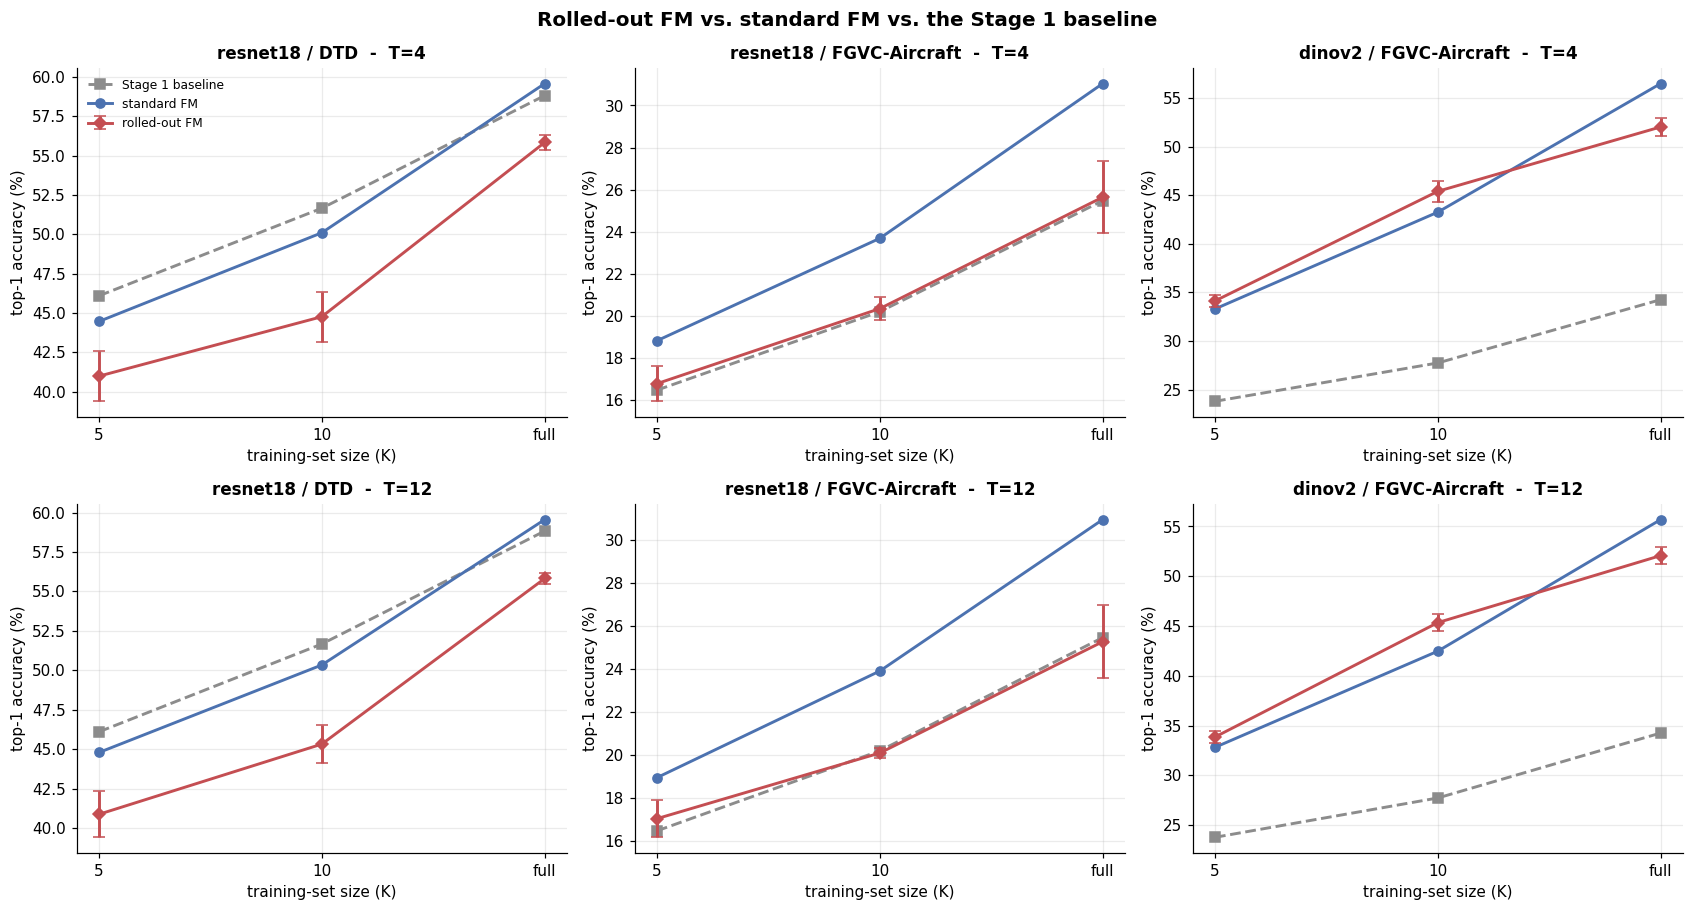

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4))

for col, (enc, ds) in enumerate(COMBOS):
    for row, T in enumerate(T_VALUES):
        ax = axes[row, col]
        base_vals = [baseline_acc[(enc, ds, k)] for k in ORDER]
        ax.plot(ORDER, base_vals, marker="s", lw=1.9, color="#8C8C8C", ls="--",
                label="Stage 1 baseline")

        std_vals = [standard_acc[(enc, ds, k, T)] for k in ORDER]
        ax.plot(ORDER, std_vals, marker="o", lw=1.9, color="#4C72B0",
                label="standard FM")

        sel = summary[(summary.encoder == enc) & (summary.dataset == ds)
                      & (summary["T"] == T)].set_index("K").loc[ORDER]
        ax.errorbar(ORDER, sel["mean"], yerr=sel["std"], marker="D", capsize=4,
                    lw=1.9, color="#C44E52", label="rolled-out FM")

        ax.set_title(f"{enc} / {ds}  -  T={T}", fontsize=11)
        ax.set_xlabel("training-set size (K)")
        ax.set_ylabel("top-1 accuracy (%)")
        if col == 0 and row == 0:
            ax.legend(fontsize=8)

fig.suptitle("Rolled-out FM vs. standard FM vs. the Stage 1 baseline",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "accuracy_vs_k")
plt.show()

  saved plot  -> plots/delta_comparisons.png


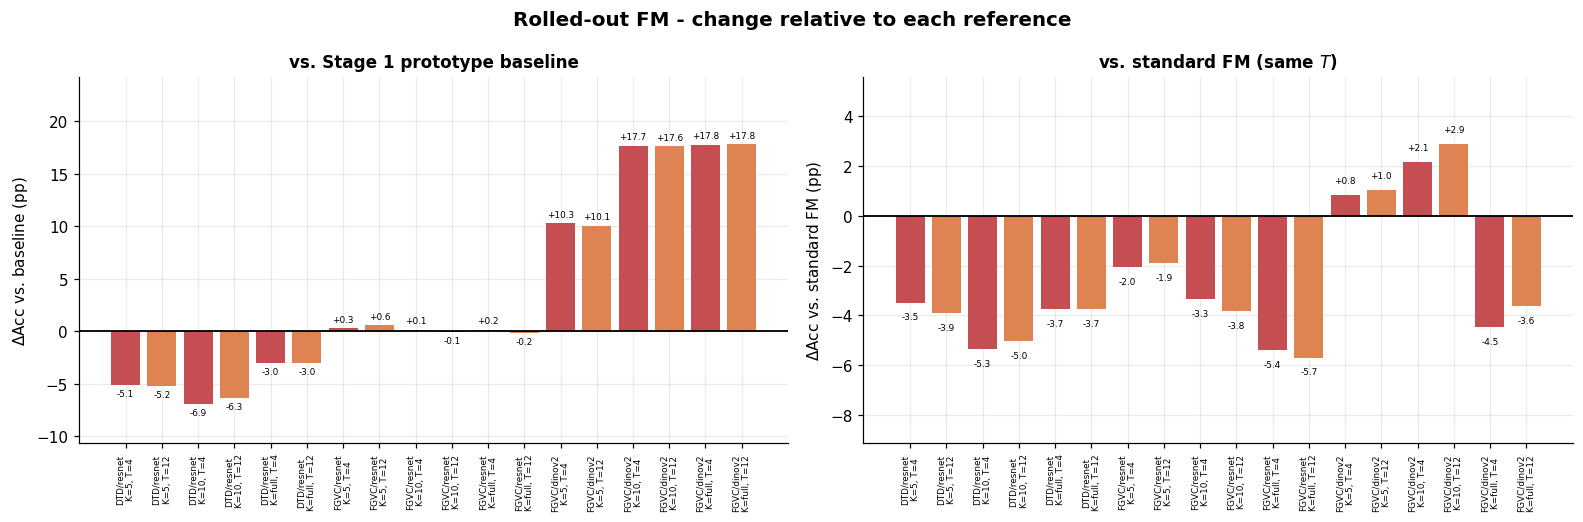

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))

for ax, (field, title, ref) in zip(axes, [
        ("delta_vs_baseline", r"vs. Stage 1 prototype baseline", "baseline"),
        ("delta_vs_standard", r"vs. standard FM (same $T$)", "standard FM")]):
    labels, vals, colors = [], [], []
    for enc, ds in COMBOS:
        for K in ORDER:
            for T, c in zip(T_VALUES, ["#C44E52", "#DD8452"]):
                row = summary[(summary.encoder == enc) & (summary.dataset == ds)
                              & (summary.K == K) & (summary["T"] == T)]
                labels.append(f"{ds[:4]}/{enc[:6]}\nK={K}, T={T}")
                vals.append(float(row[field].iloc[0]))
                colors.append(c)
    x = np.arange(len(vals))
    ax.bar(x, vals, color=colors)
    ax.axhline(0, color="black", lw=1.2)
    ax.set_ylim(min(vals) - abs(min(vals)) * 0.25 - 2, max(vals) + abs(max(vals)) * 0.25 + 2)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=5.8, rotation=90)
    ax.set_ylabel(f"$\\Delta$Acc vs. {ref} (pp)")
    ax.set_title(title, fontsize=11)
    for xi, d in zip(x, vals):
        ax.text(xi, d + (0.4 if d >= 0 else -0.4), f"{d:+.1f}", ha="center",
                va="bottom" if d >= 0 else "top", fontsize=5.8)

fig.suptitle("Rolled-out FM - change relative to each reference",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "delta_comparisons")
plt.show()

## 5 · Training curves

Note the losses of the two objectives are **not** directly comparable: standard FM measures
velocity error at a sampled time, rolled-out measures endpoint distance after $T$ steps. Each
is only meaningful against itself.

  saved plot  -> plots/training_curves.png


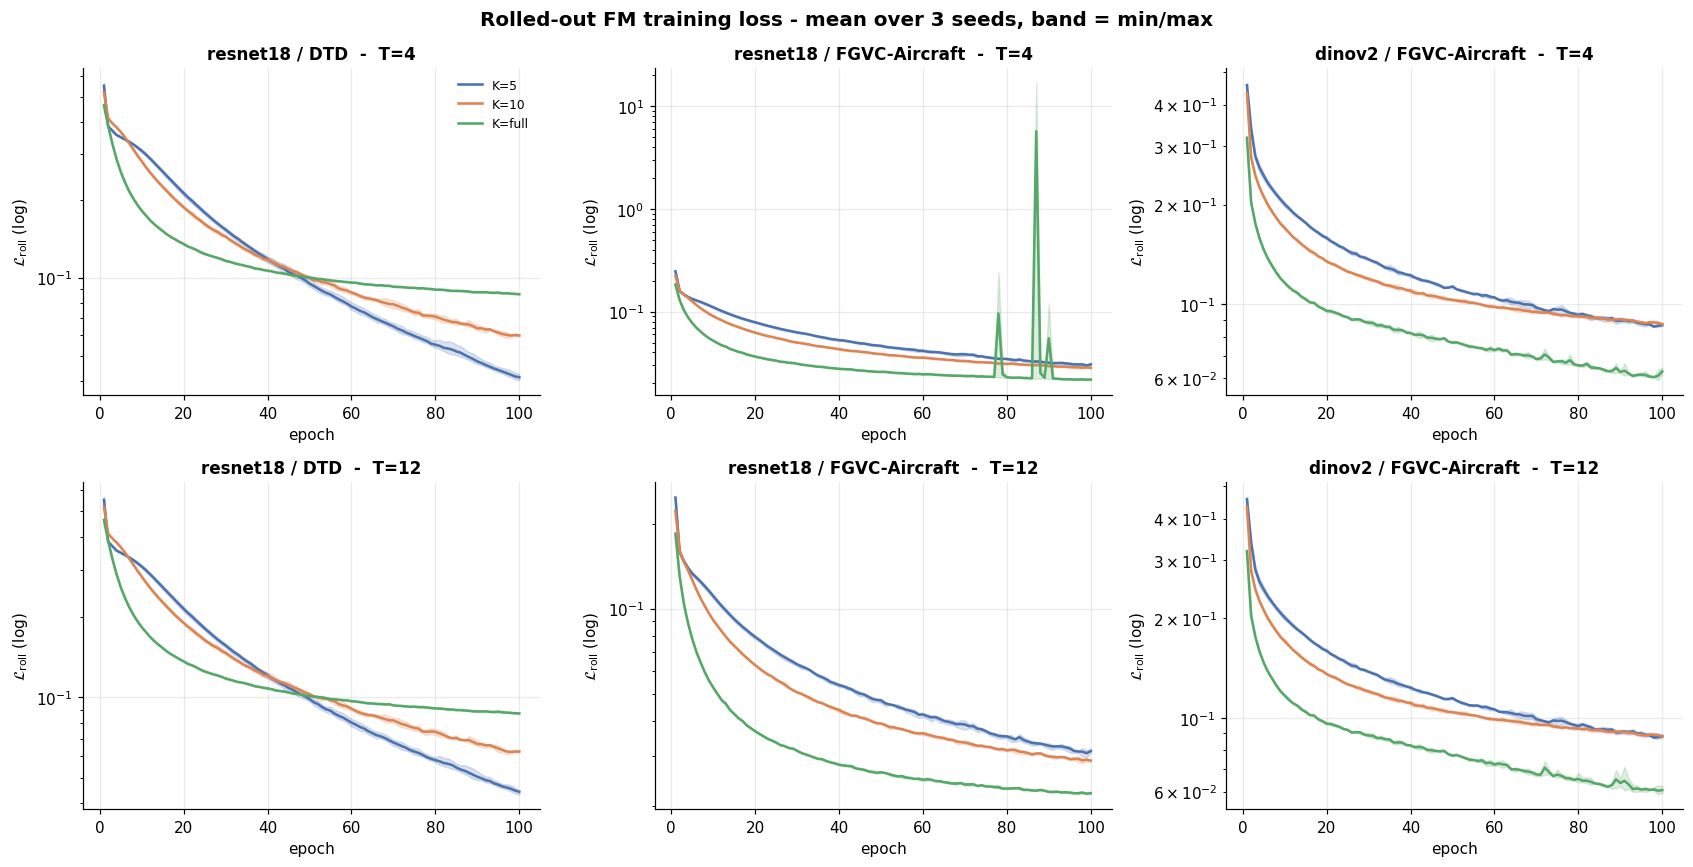

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15.5, 8))

for col, (enc, ds) in enumerate(COMBOS):
    for row, T in enumerate(T_VALUES):
        ax = axes[row, col]
        for K, color in zip(ORDER, ["#4C72B0", "#DD8452", "#55A868"]):
            hist = np.array([curves[f"{enc}__{ds}__K{K}__seed{s}__T{T}"] for s in SEEDS])
            epochs = np.arange(1, hist.shape[1] + 1)
            ax.plot(epochs, hist.mean(0), color=color, lw=1.7, label=f"K={K}")
            ax.fill_between(epochs, hist.min(0), hist.max(0), color=color, alpha=0.20)
        ax.set_yscale("log")
        ax.set_xlabel("epoch"); ax.set_ylabel(r"$\mathcal{L}_{\mathrm{roll}}$ (log)")
        ax.set_title(f"{enc} / {ds}  -  T={T}", fontsize=11)
        if col == 0 and row == 0:
            ax.legend(fontsize=8)

fig.suptitle("Rolled-out FM training loss - mean over 3 seeds, band = min/max",
             fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "training_curves")
plt.show()

In [9]:
stab_rows = []
for enc, ds in COMBOS:
    for K in ORDER:
        for T in T_VALUES:
            hist = np.array([curves[f"{enc}__{ds}__K{K}__seed{s}__T{T}"] for s in SEEDS])
            first, last = hist[:, 0].mean(), hist[:, -1].mean()
            improvement = ((hist[:, -20:-10].mean(1) - hist[:, -10:].mean(1))
                           / hist[:, -20:-10].mean(1) * 100)
            stab_rows.append({
                "encoder": enc, "dataset": ds, "K": K, "T": T,
                "loss_start": round(float(first), 4),
                "loss_end": round(float(last), 5),
                "reduction_%": round(float((first - last) / first * 100), 1),
                "last_10ep_improvement_%": round(float(improvement.mean()), 3),
                "seed_spread_end": round(float(hist[:, -1].std()), 6),
            })

stability = pd.DataFrame(stab_rows)
art.table(stability, "training_stability")
stability

  saved table -> tables/training_stability.csv  (18 rows)


,encoder,dataset,K,T,loss_start,loss_end,reduction_%,last_10ep_improvement_%,seed_spread_end
0,resnet18,DTD,5,4,0.5507,0.04124,92.5,14.595,0.000944
1,resnet18,DTD,5,12,0.5505,0.04423,92.0,13.435,0.000677
2,resnet18,DTD,10,4,0.5195,0.05979,88.5,8.203,0.000508
3,resnet18,DTD,10,12,0.5193,0.06263,87.9,8.183,0.000706
4,resnet18,DTD,full,4,0.4628,0.08632,81.3,1.842,0.000196
5,resnet18,DTD,full,12,0.4627,0.08701,81.2,1.897,0.000277
6,resnet18,FGVC-Aircraft,5,4,0.2474,0.03065,87.6,6.305,0.000433
7,resnet18,FGVC-Aircraft,5,12,0.2471,0.03125,87.4,6.099,0.000425
8,resnet18,FGVC-Aircraft,10,4,0.2218,0.02838,87.2,4.813,0.000136
9,resnet18,FGVC-Aircraft,10,12,0.2217,0.02891,87.0,4.559,0.000170


### The instability that motivated clipping

Kept as evidence rather than removed. `results/rolled_out_fm_curves_noclip.json` holds the
run recorded **before** gradient clipping was introduced: the same configuration, the same
seed, diverging at epoch 98 after 97 stable epochs.

This matters for the comparison. Standard FM never diverged in 27 unclipped runs; the
rolled-out objective did in 1 of 54. Clipping makes the accuracy numbers fair to both
methods, but the underlying difference in numerical robustness is a genuine property of
backpropagating through a rollout — so it is reported, not hidden.

  saved plot  -> plots/clipping_evidence.png


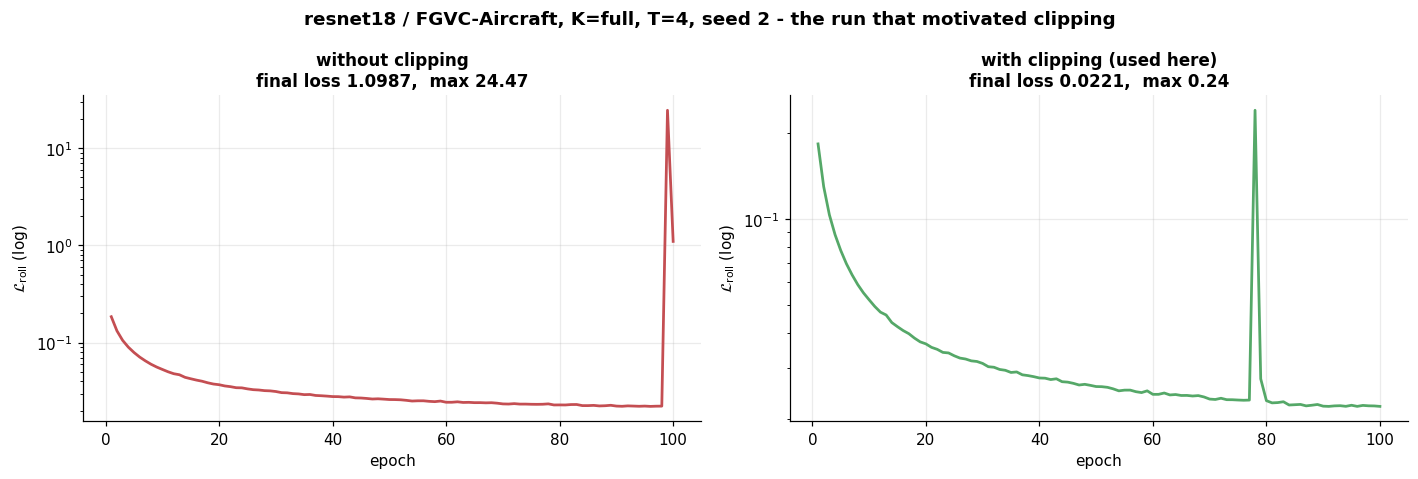

without clipping: min 0.0221 at epoch 96, max 24.47 at epoch 99, final 1.0987
with clipping   : min 0.0221 at epoch 100, max 0.24 at epoch 78, final 0.0221


In [10]:
noclip_path = RESULTS_ROOT / "rolled_out_fm_curves_noclip.json"

if noclip_path.exists():
    with open(noclip_path) as f:
        noclip = json.load(f)

    key = "resnet18__FGVC-Aircraft__Kfull__seed2__T4"
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

    for ax, (hist, tag, color) in zip(axes, [
            (noclip[key], "without clipping", "#C44E52"),
            (curves[key], "with clipping (used here)", "#55A868")]):
        h = np.array(hist)
        ax.plot(np.arange(1, len(h) + 1), h, color=color, lw=1.8)
        ax.set_yscale("log")
        ax.set_xlabel("epoch"); ax.set_ylabel(r"$\mathcal{L}_{\mathrm{roll}}$ (log)")
        ax.set_title(f"{tag}\nfinal loss {h[-1]:.4f},  max {h.max():.2f}", fontsize=11)

    fig.suptitle("resnet18 / FGVC-Aircraft, K=full, T=4, seed 2 - the run that motivated "
                 "clipping", fontsize=12, fontweight="bold")
    fig.tight_layout()
    art.figure(fig, "clipping_evidence")
    plt.show()

    spike = np.array(noclip[key])
    print(f"without clipping: min {spike.min():.4f} at epoch {spike.argmin()+1}, "
          f"max {spike.max():.2f} at epoch {spike.argmax()+1}, final {spike[-1]:.4f}")
    kept = np.array(curves[key])
    print(f"with clipping   : min {kept.min():.4f} at epoch {kept.argmin()+1}, "
          f"max {kept.max():.2f} at epoch {kept.argmax()+1}, final {kept[-1]:.4f}")
else:
    print("no unclipped reference on disk - skipping")

## 6 · Why the two objectives disagree

Rolled-out training optimises its own loss far more aggressively than standard FM optimises
its own — yet that does not automatically translate into better classification. The diagnostic
below separates the two possibilities:

- the transport **fails to reach** the prototype (underfitting), or
- it reaches the prototype **on training data only** (the transport itself overfits).

For the representative configuration (full data, seed 0) it measures the mean distance
$\lVert \hat z_T - p_{y} \rVert$ separately on the training and test splits, for both
objectives. A small train distance with a large test distance is the signature of a transport
that memorised where its training points had to go.

In [11]:
diag_rows = []

for enc, ds in COMBOS:
    tr, te = features[(enc, ds, "train")], features[(enc, ds, "test")]
    protos = prototypes[proto_key(enc, ds, "full", None)].to(DEVICE)
    z_tr = l2_normalize(tr.features).to(DEVICE)
    z_te = l2_normalize(te.features).to(DEVICE)
    p_tr, p_te = protos[tr.labels.to(DEVICE)], protos[te.labels.to(DEVICE)]

    def endpoint_gap(state_dict, T):
        net = VelocityNet(tr.dim, CONFIG.hidden_dim, CONFIG.n_hidden).to(DEVICE)
        net.load_state_dict(state_dict)
        net.eval()
        with torch.no_grad():
            d_tr = (euler_rollout(net, z_tr, T) - p_tr).norm(dim=1).mean().item()
            d_te = (euler_rollout(net, z_te, T) - p_te).norm(dim=1).mean().item()
        return d_tr, d_te

    # Distance before any transport, as the reference point.
    diag_rows.append({
        "encoder": enc, "dataset": ds, "method": "no transport", "T": "-",
        "train_gap": round((z_tr - p_tr).norm(dim=1).mean().item(), 4),
        "test_gap": round((z_te - p_te).norm(dim=1).mean().item(), 4),
    })

    for T in T_VALUES:
        d_tr, d_te = endpoint_gap(
            std_models["state_dicts"][f"{enc}__{ds}__Kfull__seed0"], T)
        diag_rows.append({"encoder": enc, "dataset": ds, "method": "standard FM",
                          "T": T, "train_gap": round(d_tr, 4), "test_gap": round(d_te, 4)})

        d_tr, d_te = endpoint_gap(
            kept_models[f"{enc}__{ds}__Kfull__seed0__T{T}"], T)
        diag_rows.append({"encoder": enc, "dataset": ds, "method": "rolled-out FM",
                          "T": T, "train_gap": round(d_tr, 4), "test_gap": round(d_te, 4)})

diagnostic = pd.DataFrame(diag_rows)
diagnostic["generalisation_gap"] = (diagnostic.test_gap - diagnostic.train_gap).round(4)
art.table(diagnostic, "transport_diagnostic")
diagnostic

  saved table -> tables/transport_diagnostic.csv  (15 rows)


,encoder,dataset,method,T,train_gap,test_gap,generalisation_gap
0,resnet18,DTD,no transport,-,0.6854,0.7068,0.0214
1,resnet18,DTD,standard FM,4,0.3343,0.4234,0.0891
2,resnet18,DTD,rolled-out FM,4,0.2759,0.3674,0.0915
3,resnet18,DTD,standard FM,12,0.3425,0.4276,0.0851
4,resnet18,DTD,rolled-out FM,12,0.2771,0.3673,0.0902
5,resnet18,FGVC-Aircraft,no transport,-,0.4332,0.4467,0.0135
6,resnet18,FGVC-Aircraft,standard FM,4,0.1851,0.2130,0.0279
7,resnet18,FGVC-Aircraft,rolled-out FM,4,0.1441,0.1680,0.0239
8,resnet18,FGVC-Aircraft,standard FM,12,0.1909,0.2180,0.0271
9,resnet18,FGVC-Aircraft,rolled-out FM,12,0.1445,0.1677,0.0232


  saved plot  -> plots/transport_diagnostic.png


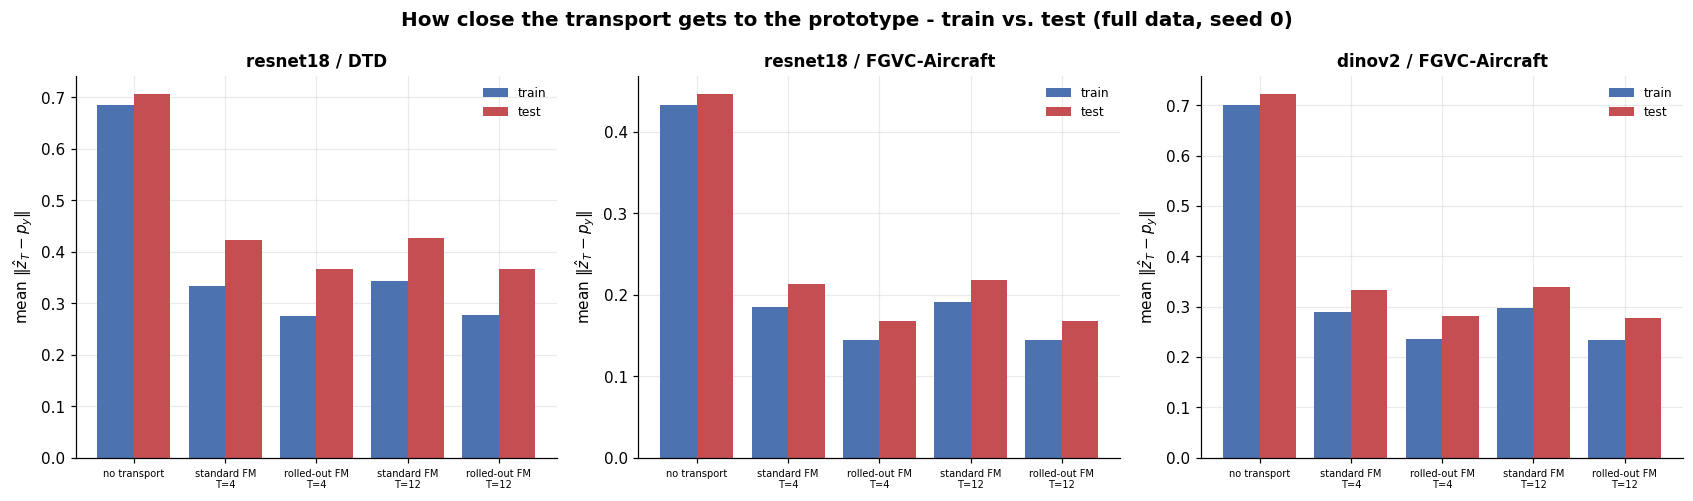

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

for ax, (enc, ds) in zip(axes, COMBOS):
    sel = diagnostic[(diagnostic.encoder == enc) & (diagnostic.dataset == ds)]
    labels = [f"{r.method}\n{'' if r['T'] == '-' else 'T=' + str(r['T'])}"
              for _, r in sel.iterrows()]
    x = np.arange(len(sel))
    ax.bar(x - 0.2, sel.train_gap, 0.4, color="#4C72B0", label="train")
    ax.bar(x + 0.2, sel.test_gap, 0.4, color="#C44E52", label="test")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=6.5)
    ax.set_ylabel(r"mean $\|\hat z_T - p_y\|$")
    ax.set_title(f"{enc} / {ds}", fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle("How close the transport gets to the prototype - train vs. test "
             "(full data, seed 0)", fontsize=13, fontweight="bold")
fig.tight_layout()
art.figure(fig, "transport_diagnostic")
plt.show()

### The transport does not overfit — so what does go wrong?

The diagnostic above rules out the obvious explanation. Rolled-out training reaches the
prototype **more** closely than standard FM on the *test* split as well as on train, and its
train/test gap is no larger. The transport generalises perfectly well.

The mismatch is between the **objective and the decision rule**:

$$\mathcal{L}_\mathrm{roll} = \lVert \hat z_T - p_{y} \rVert_2^2
\qquad\text{but}\qquad
\hat y = \arg\max_c \cos(\hat z_T,\, \mu_c)$$

The loss rewards **absolute proximity** to one prototype. The classifier reads a **relative**
quantity — whether the correct prototype is closer *than every other one*. Driving a feature
hard toward its own prototype also drags it into the neighbourhood of adjacent prototypes, so
absolute distance improves while the margin that actually decides the label shrinks.

The measurement below reports, on the test split, the similarity to the **correct** prototype,
the similarity to the **best competing** prototype, and their difference — the margin

$$m = \cos(\hat z_T, \mu_{y}) \;-\; \max_{c \neq y} \cos(\hat z_T, \mu_c)$$

**A caveat on reading the margin.** Accuracy *is* the fraction of examples with $m > 0$, so
"accuracy fell because the margin fell" is close to a restatement rather than an explanation.
The genuinely informative columns are the first two: if rolled-out raises similarity to the
correct prototype **and** to competing prototypes together, then it is compressing features
toward the whole prototype cloud rather than sharpening the decision — absolute proximity
improving while discrimination does not.

In [13]:
margin_rows = []

for enc, ds in COMBOS:
    te = features[(enc, ds, "test")]
    protos = prototypes[proto_key(enc, ds, "full", None)].to(DEVICE)
    z = l2_normalize(te.features).to(DEVICE)
    y = te.labels.to(DEVICE)

    def margin_stats(z_out, method, T):
        sims = l2_normalize(z_out) @ protos.T
        own = sims.gather(1, y[:, None]).squeeze(1)
        others = sims.clone()
        others.scatter_(1, y[:, None], -2.0)
        runner_up = others.max(dim=1).values
        return {
            "encoder": enc, "dataset": ds, "method": method, "T": T,
            "cos_own": round(own.mean().item(), 4),
            "cos_runner_up": round(runner_up.mean().item(), 4),
            "margin": round((own - runner_up).mean().item(), 4),
            "test_acc": round(100 * (sims.argmax(1) == y).float().mean().item(), 2),
        }

    margin_rows.append(margin_stats(z, "no transport", "-"))

    for T in T_VALUES:
        for method, store in [("standard FM", std_models["state_dicts"][f"{enc}__{ds}__Kfull__seed0"]),
                              ("rolled-out FM", kept_models[f"{enc}__{ds}__Kfull__seed0__T{T}"])]:
            net_m = VelocityNet(te.dim, CONFIG.hidden_dim, CONFIG.n_hidden).to(DEVICE)
            net_m.load_state_dict(store)
            net_m.eval()
            with torch.no_grad():
                margin_rows.append(margin_stats(euler_rollout(net_m, z, T), method, T))

margins = pd.DataFrame(margin_rows)
art.table(margins, "margin_analysis")
margins

  saved table -> tables/margin_analysis.csv  (15 rows)


,encoder,dataset,method,T,cos_own,cos_runner_up,margin,test_acc
0,resnet18,DTD,no transport,-,0.7441,0.7313,0.0128,58.83
1,resnet18,DTD,standard FM,4,0.9071,0.8961,0.0110,58.88
2,resnet18,DTD,rolled-out FM,4,0.9265,0.9219,0.0046,55.32
3,resnet18,DTD,standard FM,12,0.9057,0.8944,0.0113,58.78
4,resnet18,DTD,rolled-out FM,12,0.9259,0.9210,0.0049,55.48
5,resnet18,FGVC-Aircraft,no transport,-,0.8972,0.9066,-0.0094,25.47
6,resnet18,FGVC-Aircraft,standard FM,4,0.9766,0.9792,-0.0027,31.53
7,resnet18,FGVC-Aircraft,rolled-out FM,4,0.9851,0.9880,-0.0029,26.13
8,resnet18,FGVC-Aircraft,standard FM,12,0.9755,0.9782,-0.0027,31.26
9,resnet18,FGVC-Aircraft,rolled-out FM,12,0.9853,0.9882,-0.0029,25.68


  saved plot  -> plots/margin_analysis.png


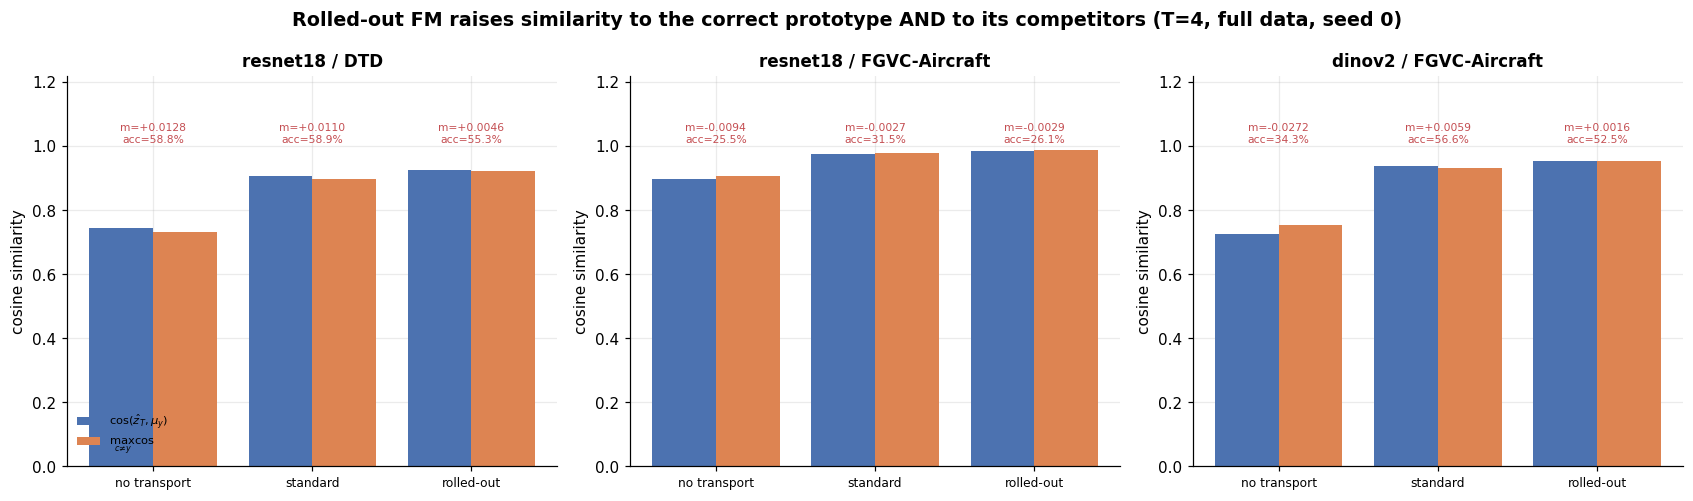

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

for ax, (enc, ds) in zip(axes, COMBOS):
    sel = margins[(margins.encoder == enc) & (margins.dataset == ds)
                  & (margins["T"].isin(["-", 4]))]
    labels = [r.method.replace(" FM", "") for _, r in sel.iterrows()]
    x = np.arange(len(sel))

    ax.bar(x - 0.2, sel.cos_own, 0.4, color="#4C72B0", label=r"$\cos(\hat z_T, \mu_y)$")
    ax.bar(x + 0.2, sel.cos_runner_up, 0.4, color="#DD8452", label=r"$\max_{c \neq y}\cos$")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("cosine similarity")
    ax.set_ylim(0, 1.22)
    ax.set_title(f"{enc} / {ds}", fontsize=11)

    # Margin and accuracy printed as text rather than drawn on a second axis: the
    # differences are O(1e-3) and an auto-scaled axis makes a 0.0002 change look like a
    # cliff. Numbers cannot mislead the way a rescaled line can.
    for xi, (_, r) in zip(x, sel.iterrows()):
        ax.text(xi, 1.005, f"m={r.margin:+.4f}\nacc={r.test_acc:.1f}%",
                ha="center", va="bottom", fontsize=7, color="#C44E52")

    if ax is axes[0]:
        ax.legend(fontsize=7.5, loc="lower left")

fig.suptitle("Rolled-out FM raises similarity to the correct prototype AND to its "
             "competitors (T=4, full data, seed 0)", fontsize=12.5, fontweight="bold")
fig.tight_layout()
art.figure(fig, "margin_analysis")
plt.show()

**What the numbers support, and what they do not.**

Consistent across **all three** combinations: rolled-out FM raises
$\cos(\hat z_T, \mu_y)$ *and* $\max_{c \neq y}\cos(\hat z_T, \mu_c)$ relative to standard FM,
while accuracy falls. It pulls each feature closer to its own prototype and closer to the
competing ones at the same time. That is the mechanism — the transport succeeds at what it
was asked to do (minimise distance to one prototype) and that objective simply does not
require the result to be *more distinguishable* from the others.

Supported in two of three: the mean margin roughly halves on DTD ($0.0110 \to 0.0046$) and
falls about fourfold on DINOv2/Aircraft ($0.0059 \to 0.0016$). On ResNet-18/Aircraft it is
essentially unchanged ($-0.0027 \to -0.0029$) even though accuracy drops 5.4 pp, so the mean
margin is **not** a reliable summary there — with accuracy near 26 %, most examples sit on
the wrong side of zero and the mean is dominated by how badly they fail rather than by the
decision boundary.

This is why the conclusion is drawn from the two similarity columns rather than from the
margin alone.

## 7 · Save artefacts

In [15]:
runs.to_csv(RESULTS_ROOT / "rolled_out_fm_runs.csv", index=False)
with open(RESULTS_ROOT / "rolled_out_fm_curves.json", "w") as f:
    json.dump(curves, f)
torch.save(predictions, RESULTS_ROOT / "rolled_out_fm_predictions.pt")
torch.save({"state_dicts": kept_models, "config": CONFIG.as_dict(),
            "note": "full-data seed-0 runs, one per T, kept for step 5 visualisations"},
           RESULTS_ROOT / "rolled_out_fm_models.pt")

for name in ("rolled_out_fm_runs.csv", "rolled_out_fm_curves.json",
             "rolled_out_fm_predictions.pt", "rolled_out_fm_models.pt"):
    print(f"  results/{name:36s} {(RESULTS_ROOT / name).stat().st_size / 1024:9.1f} KB")

methodology = pd.DataFrame([
    {"item": "objective", "value": "L_roll = ||z_T - p||^2, backpropagated through all T steps"},
    {"item": "rollout", "value": "cvlabfm.flow.euler_rollout - the same function used at inference"},
    {"item": "T at training", "value": "equal to T at inference, by construction"},
    {"item": "architecture", "value": f"identical to step 2: MLP {CONFIG.n_hidden} x {CONFIG.hidden_dim}, SiLU"},
    {"item": "optimiser", "value": f"identical to step 2: {CONFIG.optimizer}, lr {CONFIG.lr}, wd {CONFIG.weight_decay}, batch {CONFIG.batch_size}"},
    {"item": "gradient clipping", "value": f"norm {CONFIG.max_grad_norm} - added for this objective's stability, applied to step 2 as well to keep them identical"},
    {"item": "epochs", "value": f"{CONFIG.epochs} - identical to step 2, deliberately not re-tuned"},
    {"item": "normalization", "value": "L2-normalized inputs, as in step 2 (ablated there)"},
    {"item": "subsets / seeds", "value": "identical to step 2 and to Stage 1"},
    {"item": "models trained", "value": "54 = 3 combos x 3 K x 3 seeds x 2 T"},
    {"item": "evaluation", "value": "each model evaluated only at the T it was trained with"},
])
art.table(methodology, "methodology")
methodology

  results/rolled_out_fm_runs.csv                     4.9 KB
  results/rolled_out_fm_curves.json                112.8 KB
  results/rolled_out_fm_predictions.pt            1217.9 KB
  results/rolled_out_fm_models.pt                17466.5 KB
  saved table -> tables/methodology.csv  (11 rows)


,item,value
0,objective,"L_roll = ||z_T - p||^2, backpropagated through..."
1,rollout,cvlabfm.flow.euler_rollout - the same function...
2,T at training,"equal to T at inference, by construction"
3,architecture,"identical to step 2: MLP 2 x 512, SiLU"
4,optimiser,"identical to step 2: AdamW, lr 0.001, wd 0.000..."
5,gradient clipping,norm 1.0 - added for this objective's stabilit...
6,epochs,"100 - identical to step 2, deliberately not re..."
7,normalization,"L2-normalized inputs, as in step 2 (ablated th..."
8,subsets / seeds,identical to step 2 and to Stage 1
9,models trained,54 = 3 combos x 3 K x 3 seeds x 2 T


## 8 · Manifest

In [16]:
art.manifest()

12 artefacts in C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_2\Work\03_rolled_out_fm


,kind,file,size_KB
0,plot,plots/accuracy_vs_k.png,251.2
1,plot,plots/clipping_evidence.png,70.9
2,plot,plots/delta_comparisons.png,77.4
3,plot,plots/margin_analysis.png,63.3
4,plot,plots/train_inference_mismatch.png,96.6
5,plot,plots/training_curves.png,304.2
6,plot,plots/transport_diagnostic.png,56.3
7,table,tables/accuracy_summary.csv,1.5
8,table,tables/margin_analysis.csv,1.0
9,table,tables/methodology.csv,0.8


---

## Next step

**Step 04 — Evaluation.** Assembles the headline results from steps 2 and 3's saved
results: the full accuracy table across all five methods (baseline, standard FM at $T \in
\{4, 12\}$, rolled-out FM at $T \in \{4, 12\}$), $\Delta\mathrm{Acc}$ against the baseline,
the accuracy-versus-$K$ plot with error bars, and representative training curves for both
objectives side by side.